In [1]:
# Step 1 : Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Step 2 : Load Correct Excel File

df = pd.read_excel("COVID_Stock_Monthly_55rows.xlsx")

# Show First 5 Rows
print(df.head())

       Date  Confirmed  Recovered  Deaths   Active       Trend  NIFTY_Open  \
0  Jan-2020    2220110    1701906   27845   490359  Increasing       13232   
1  Feb-2020    2769307    1442539   62141  1264627  Increasing        9853   
2  Mar-2020    2230084    1724736   51308   454040  Decreasing       13616   
3  Apr-2020    3512566    2025822  137637  1349107  Increasing       14585   
4  May-2020    2357330    1247671   83690  1025969  Decreasing       12659   

   NIFTY_High  NIFTY_Low  NIFTY_Close  NIFTY_Volume  
0       13439      12882        12918      13849851  
1        9983       9399         9678      23762804  
2       13767      13399        13579      25974571  
3       14638      14339        14433      23529899  
4       13048      12561        12929      29494084  


In [6]:
# Step 3 : Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          55 non-null     object
 1   Confirmed     55 non-null     int64 
 2   Recovered     55 non-null     int64 
 3   Deaths        55 non-null     int64 
 4   Active        55 non-null     int64 
 5   Trend         55 non-null     object
 6   NIFTY_Open    55 non-null     int64 
 7   NIFTY_High    55 non-null     int64 
 8   NIFTY_Low     55 non-null     int64 
 9   NIFTY_Close   55 non-null     int64 
 10  NIFTY_Volume  55 non-null     int64 
dtypes: int64(9), object(2)
memory usage: 4.9+ KB
None


In [7]:
# Step 4 : Statistical Summary

print(df.describe())

          Confirmed     Recovered         Deaths        Active    NIFTY_Open  \
count  5.500000e+01  5.500000e+01      55.000000  5.500000e+01     55.000000   
mean   1.783523e+06  1.271745e+06   53314.272727  4.584635e+05  12079.345455   
std    1.049093e+06  8.013023e+05   37306.141417  3.839751e+05   2200.757506   
min    6.672500e+04  4.568000e+04    1267.000000  4.071000e+03   8197.000000   
25%    9.361585e+05  6.704065e+05   24252.500000  1.363465e+05  10243.500000   
50%    1.767891e+06  1.215999e+06   51308.000000  3.914990e+05  12097.000000   
75%    2.500783e+06  1.805654e+06   76447.000000  7.224015e+05  13774.000000   
max    3.531409e+06  3.334000e+06  159614.000000  1.377261e+06  15974.000000   

         NIFTY_High     NIFTY_Low   NIFTY_Close  NIFTY_Volume  
count     55.000000     55.000000     55.000000  5.500000e+01  
mean   12377.272727  11812.836364  12117.872727  1.674192e+07  
std     2200.207124   2189.536064   2220.123496  7.787941e+06  
min     8245.000000   7

In [8]:
# Step 5 : Check Missing Values

print(df.isnull().sum())

Date            0
Confirmed       0
Recovered       0
Deaths          0
Active          0
Trend           0
NIFTY_Open      0
NIFTY_High      0
NIFTY_Low       0
NIFTY_Close     0
NIFTY_Volume    0
dtype: int64


In [9]:
# Step 6 : Convert Date Column to Datetime

df['Date'] = pd.to_datetime(df['Date'], format='%b-%Y')

# Sort Data by Date
df = df.sort_values('Date')

print(df.head())

        Date  Confirmed  Recovered  Deaths   Active       Trend  NIFTY_Open  \
0 2020-01-01    2220110    1701906   27845   490359  Increasing       13232   
1 2020-02-01    2769307    1442539   62141  1264627  Increasing        9853   
2 2020-03-01    2230084    1724736   51308   454040  Decreasing       13616   
3 2020-04-01    3512566    2025822  137637  1349107  Increasing       14585   
4 2020-05-01    2357330    1247671   83690  1025969  Decreasing       12659   

   NIFTY_High  NIFTY_Low  NIFTY_Close  NIFTY_Volume  
0       13439      12882        12918      13849851  
1        9983       9399         9678      23762804  
2       13767      13399        13579      25974571  
3       14638      14339        14433      23529899  
4       13048      12561        12929      29494084  


In [10]:
# Step 8 : Final Null Check + Cleaning

print(df.isnull().sum())

# (Optional) Drop duplicates if any
df = df.drop_duplicates()

print("Data cleaned successfully")

Date            0
Confirmed       0
Recovered       0
Deaths          0
Active          0
Trend           0
NIFTY_Open      0
NIFTY_High      0
NIFTY_Low       0
NIFTY_Close     0
NIFTY_Volume    0
dtype: int64
Data cleaned successfully


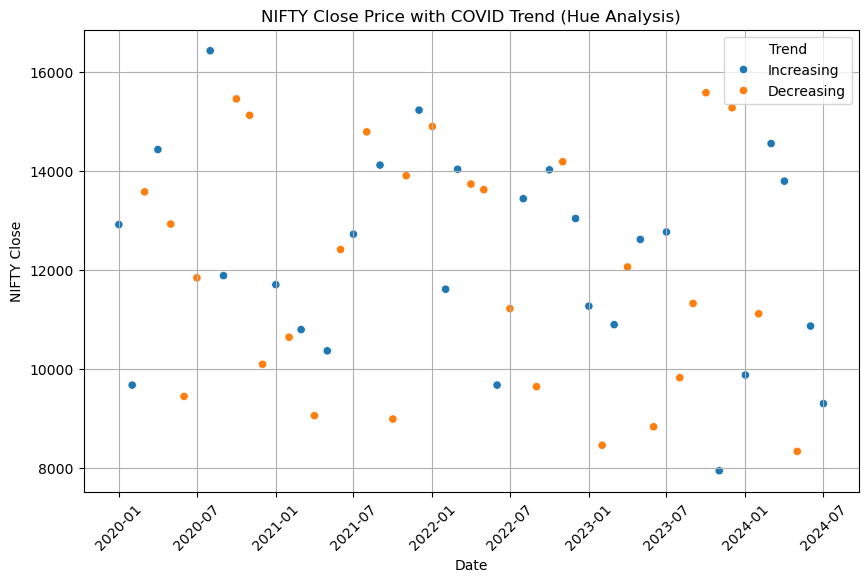

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Date',
    y='NIFTY_Close',
    hue='Trend'
)

plt.title("NIFTY Close Price with COVID Trend (Hue Analysis)")
plt.xlabel("Date")
plt.ylabel("NIFTY Close")
plt.xticks(rotation=45)
plt.grid(True)

plt.show() 


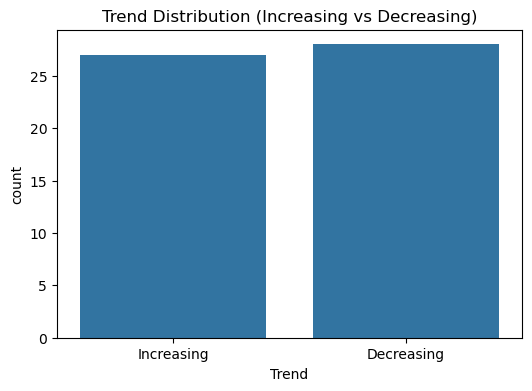

In [13]:
# Trend distribution (FIXED)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Trend')

plt.title("Trend Distribution (Increasing vs Decreasing)")
plt.show()

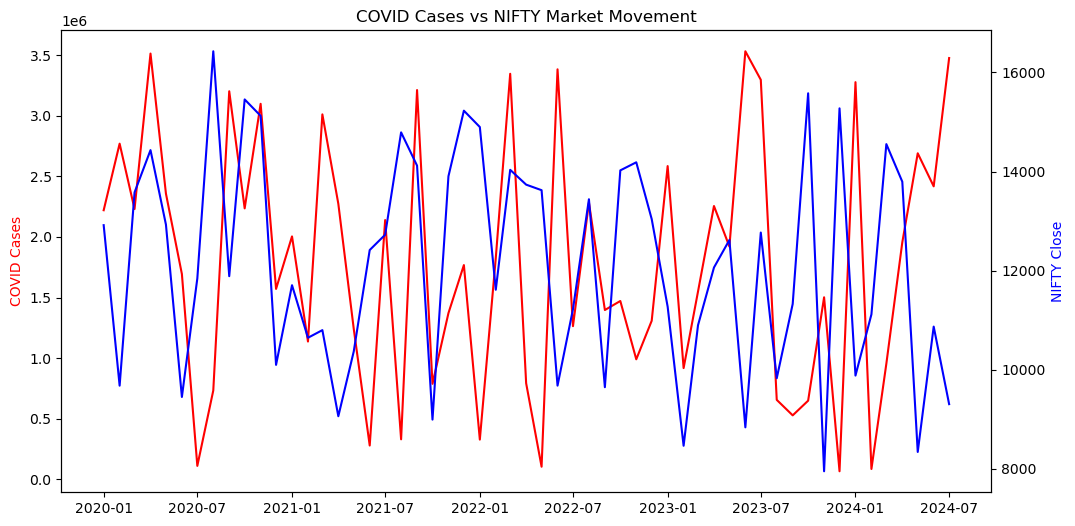

In [14]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Confirmed'], color='red', label='COVID Confirmed')
ax1.set_ylabel('COVID Cases', color='red')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['NIFTY_Close'], color='blue', label='NIFTY Close')
ax2.set_ylabel('NIFTY Close', color='blue')

plt.title("COVID Cases vs NIFTY Market Movement")
plt.show()

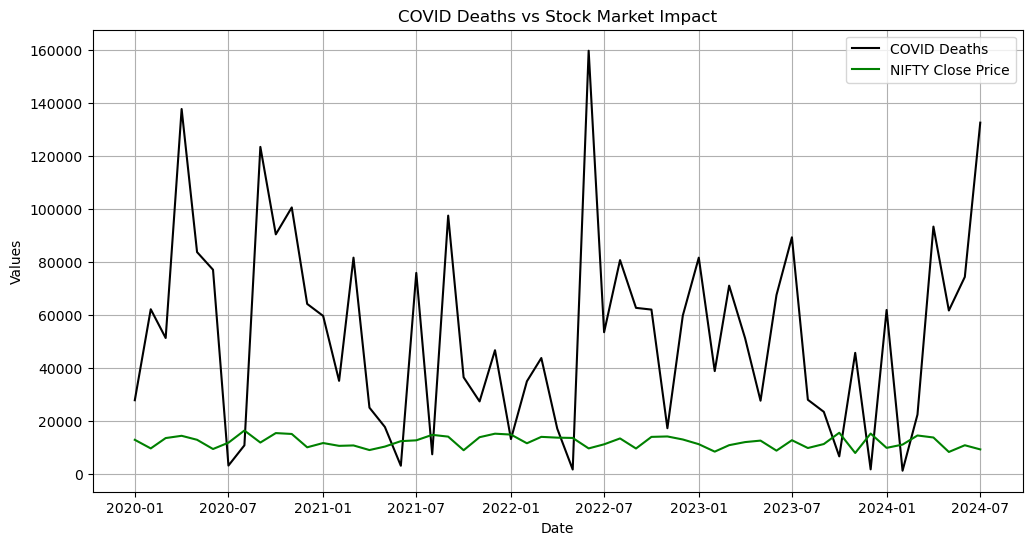

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Deaths'], label='COVID Deaths', color='black')
plt.plot(df['Date'], df['NIFTY_Close'], label='NIFTY Close Price', color='green')

plt.xlabel("Date")
plt.ylabel("Values")
plt.title("COVID Deaths vs Stock Market Impact")
plt.legend()
plt.grid(True)

plt.show()

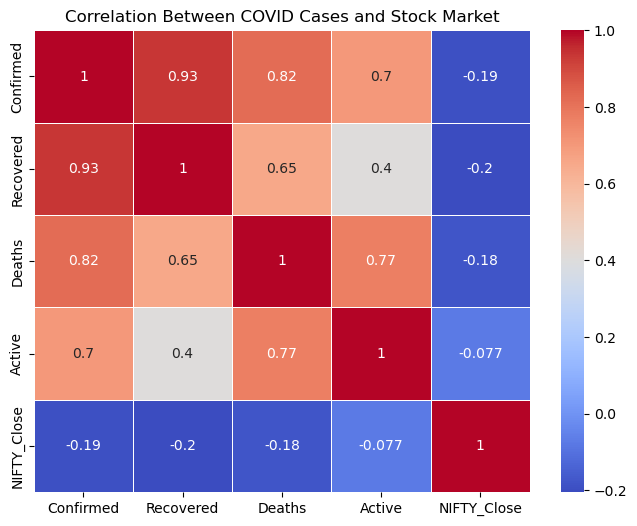

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Confirmed','Recovered','Deaths','Active','NIFTY_Close']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Between COVID Cases and Stock Market")
plt.show()

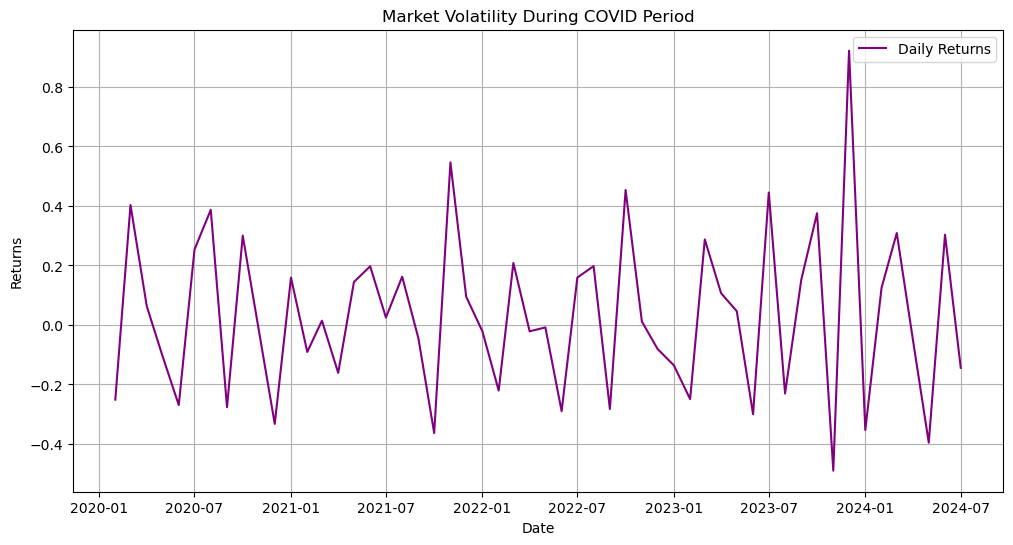

In [18]:
df['returns'] = df['NIFTY_Close'].pct_change()

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['returns'], color='purple', label='Daily Returns')

plt.xlabel("Date")
plt.ylabel("Returns")
plt.title("Market Volatility During COVID Period")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
🚀 Final Summary (Chart Based)
COVID rise → Market fall 📉
COVID control → Market recovery 📈
Deaths increase → Panic in market 😟
Volume increase → High uncertainty trading ⚡

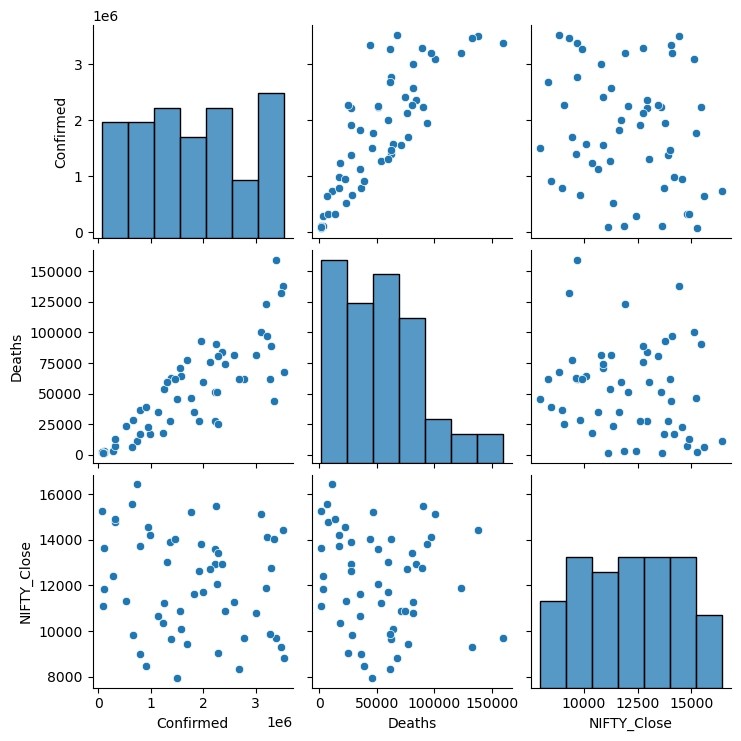

In [19]:
sns.pairplot(df[['Confirmed','Deaths','NIFTY_Close']])

In [20]:
df['returns'] = df['NIFTY_Close'].pct_change()

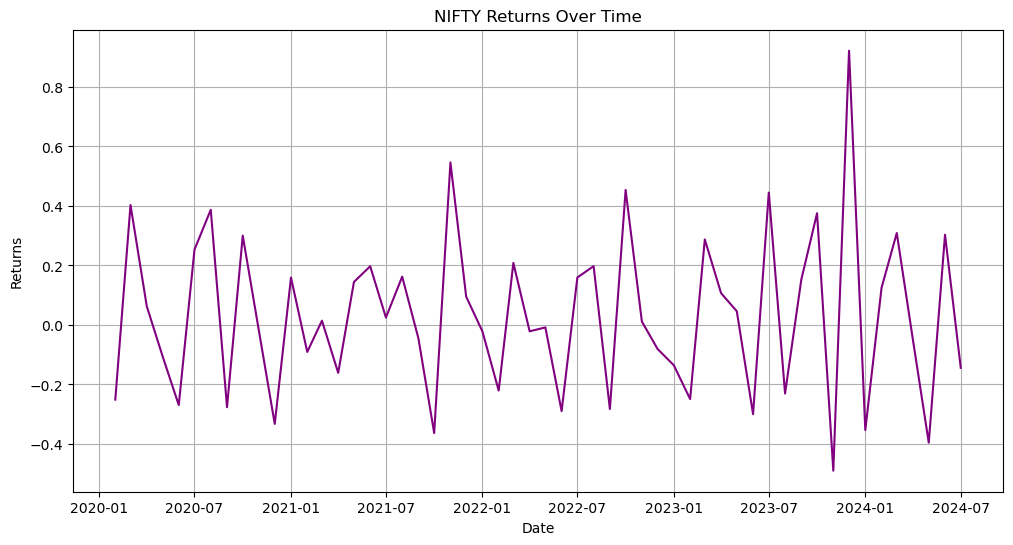

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['returns'], color='purple')

plt.title("NIFTY Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(True)

plt.show()